## Lab 7.2: Stereo

In this lab you will implement a simple stereo block-matching algorithm to estimate a depth map from a stereo pair.

In [1]:
import matplotlib.pyplot as plt

import numpy as np
import imageio
import skimage
from skimage.color import rgb2gray

from scipy.ndimage import convolve

Let's load our Bennu stereo pair.  By inspecting the images you can see that as you go from the left image to the right image, the points in the scene move to the left, as you would expect.

C:\tmp\ipykernel_12156\2631425911.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  left = rgb2gray(imageio.imread('toys_left.png'))
C:\tmp\ipykernel_12156\2631425911.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  right = rgb2gray(imageio.imread('toys_right.png'))


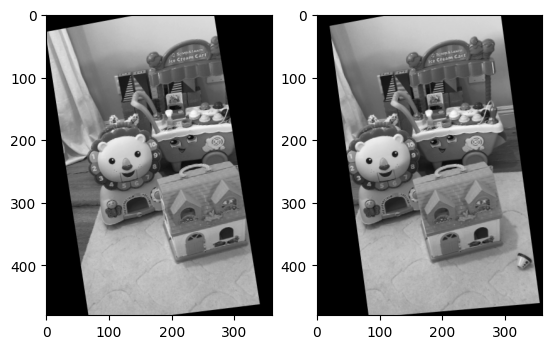

In [13]:
left = rgb2gray(imageio.imread('toys_left.png'))
right = rgb2gray(imageio.imread('toys_right.png'))

fig,axes = plt.subplots(1,2)
axes[0].imshow(left,cmap='gray')
axes[1].imshow(right,cmap='gray')

Now you will write a simple stereo block matching algorithm to estimate the disparity of each pixel in the left image (how far the pixel moved to the left in the right image).

First choose a maximum disparity -- I chose a maximum of 35 pixels.  

Make a cost volume to store the results.  The cost volume will have size $H \times W \times D$ where $H \times W$ is the size of the images and and $D$ is the number of disparity settings.  Initialize the cost volume to have a value of infinity at all locations.

What we will do is shift the left image by each disparity setting and compare it to the right image.

For each disparity setting $d$ from 0 to the maximum, do the following:
- Take columns $d$ to $W-1$ in the left image and columns $0$ to $W-d-1$ in the right image.
- Compute the squared difference of the two cropped images.
- Convolve the squared difference with a box filter (a square filter of all ones).  (I used a box filter size of $5\times5$.)
- Store the result in columns $d$ to $W-1$ in layer $d$ of the cost volume.

Finally, compute the best disparity at each pixel by finding the disparity setting with lowest cost at each pixel.  (See `np.argmin`.)  The result is your disparity map.  `imshow` the disparity and verify that it matches the depth of the scene.

Try your algorithm on the Bennu stereo pair as well as "plushies" and "toys."  (Note that the Bennu stereo pair seems to have been shifted so that the closer points actually have lower disparity.)

In [15]:
def stereo(left, right):
    maximum_disparity = 35
    H, W = np.shape(left)
    cost_volume = np.full((H, W, maximum_disparity), np.inf)

    box_filter = np.ones((5,5))
    for d in range(maximum_disparity):
        cost_volume[:, d:, d] = convolve( (left[:, d:] - right[:, :W-d]) ** 2,box_filter)

    plt.imshow(np.argmin(cost_volume, axis=2), cmap="gray")

C:\tmp\ipykernel_12156\2128869370.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  stereo(rgb2gray(imageio.imread('bennu_left.png')), rgb2gray(imageio.imread('bennu_right.png')))


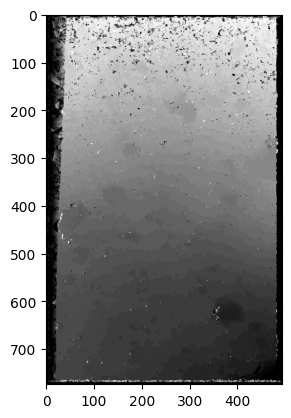

In [16]:
stereo(rgb2gray(imageio.imread('bennu_left.png')), rgb2gray(imageio.imread('bennu_right.png')))

C:\tmp\ipykernel_12156\3456036628.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  stereo(rgb2gray(imageio.imread('plushies_left.png')), rgb2gray(imageio.imread('plushies_right.png')))


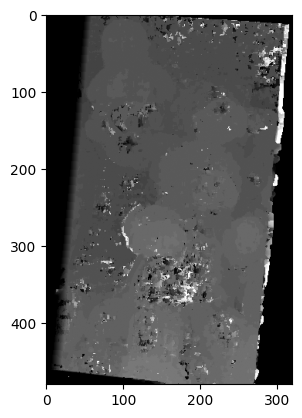

In [17]:
stereo(rgb2gray(imageio.imread('plushies_left.png')), rgb2gray(imageio.imread('plushies_right.png')))

C:\tmp\ipykernel_12156\3711582128.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  stereo(rgb2gray(imageio.imread('toys_left.png')), rgb2gray(imageio.imread('toys_right.png')))


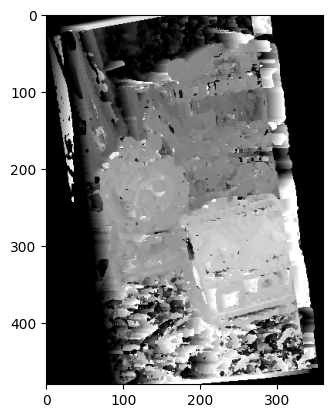

In [18]:
stereo(rgb2gray(imageio.imread('toys_left.png')), rgb2gray(imageio.imread('toys_right.png')))